In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import cudf
import cupy as cp
from cuml.preprocessing import StandardScaler
from cuml.ensemble import RandomForestClassifier
from cuml.model_selection import train_test_split
from cuml.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.metrics import roc_curve, auc, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.pruners import MedianPruner
import time

In [3]:
df = cudf.read_csv('magic04.csv', header=None)
col_names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 
    'fM3Trans', 'fAlpha', 'fDist', 'fClass'
]
df.columns = col_names

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

y = (y == 'h').astype('int32')


print(f"Dataset shape: {X.shape}")
print(f"Classes: {y.unique().to_pandas().tolist()}")
print(f"\nDataset info:")
print(f"  Samples: {len(X):,}")
print(f"  Features: {X.shape[1]}")
print(f"  Target distribution: {y.value_counts().to_pandas().to_dict()}")

Dataset shape: (19020, 10)
Classes: [0, 1]

Dataset info:
  Samples: 19,020
  Features: 10
  Target distribution: {0: 12332, 1: 6688}


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42,stratify = y)
print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (15216, 10)
Test set: (3804, 10)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
trial_results = {
    'trial_id': [],
    'accuracy': [],
    'n_estimators': [],
    'max_depth': [],
    'min_samples_split': [],
    'training_time': []
}

def objective(trial):
    
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=10)
    max_depth = trial.suggest_int('max_depth', 3, 25)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        verbose=0
    )
    
    model.fit(X_train_scaled, y_train)

    accuracy = float(model.score(X_test_scaled, y_test))
    
    # Store results
    trial_results['trial_id'].append(trial.number)
    trial_results['accuracy'].append(accuracy)
    trial_results['n_estimators'].append(n_estimators)
    trial_results['max_depth'].append(max_depth)
    trial_results['min_samples_split'].append(min_samples_split)
    
    return accuracy


study = optuna.create_study(
    direction='maximize',
    pruner=MedianPruner(n_startup_trials=5)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best Trial Number: {study.best_trial.number}")
print(f"Best Accuracy: {study.best_value:.6f}")
print(f"\nBest Hyperparameters:")
for param, value in study.best_trial.params.items():
    print(f"  {param}: {value}")

[I 2026-04-18 11:38:06,748] A new study created in memory with name: no-name-669ff9d4-e86b-4538-938a-81903dd51ee6


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-18 11:38:07,055] Trial 0 finished with value: 0.8222923238696109 and parameters: {'n_estimators': 150, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8222923238696109.
[I 2026-04-18 11:38:07,693] Trial 1 finished with value: 0.8817034700315457 and parameters: {'n_estimators': 270, 'max_depth': 25, 'min_samples_split': 8, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.8817034700315457.
[I 2026-04-18 11:38:08,346] Trial 2 finished with value: 0.8832807570977917 and parameters: {'n_estimators': 280, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.8832807570977917.
[I 2026-04-18 11:38:08,704] Trial 3 finished with value: 0.8688222923238696 and parameters: {'n_estimators': 250, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 8}. Best is trial 2 with value: 0.8832807570977917.
[I 2026-04-18 11:38:09,304] Trial 4 finished with value: 0.8859095688748686 and parameters: {'

In [7]:
try:
    trials_df = pd.DataFrame(trial_results)
except ValueError:
    trials_df = pd.concat({k: pd.Series(v) for k, v in trial_results.items()}, axis=1)

print(f"\nTop 5 Trials (by accuracy):")
print(trials_df.nlargest(5, 'accuracy')[['trial_id', 'accuracy', 'n_estimators', 'max_depth']])


Top 5 Trials (by accuracy):
    trial_id  accuracy  n_estimators  max_depth
32        32  0.889853           180         25
12        12  0.889327           230         24
42        42  0.888801           300         24
31        31  0.888275           190         25
44        44  0.888013           180         24


In [8]:
final_model = RandomForestClassifier(**study.best_params, random_state=42)

final_model.fit(X_train_scaled, y_train)

RandomForestClassifier()

In [9]:
y_pred_gpu = final_model.predict(X_test_scaled)
y_pred_proba_gpu = final_model.predict_proba(X_test_scaled).to_cupy()
y_pred_cpu = cp.asnumpy(y_pred_gpu)
y_pred_proba_cpu = cp.asnumpy(y_pred_proba_gpu[:, 1])
y_test_cpu = y_test.to_numpy()
accuracy = accuracy_score(y_test_cpu, y_pred_cpu)
fpr, tpr, _ = roc_curve(y_test_cpu, y_pred_proba_cpu)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y_test, y_pred_gpu)
cm_cpu = cp.asnumpy(cm)

print(f"Accuracy: {accuracy:.6f}")
print(f"ROC AUC: {roc_auc:.6f}")
print(f"\nConfusion Matrix:")
print(f"            Predicted")
print(f"           Signal  Background")
print(f"Signal      {int(cm_cpu[0, 0]):5d}      {int(cm_cpu[0, 1]):5d}")
print(f"Background  {int(cm_cpu[1, 0]):5d}      {int(cm_cpu[1, 1]):5d}")

Accuracy: 0.889853
ROC AUC: 0.938814

Confusion Matrix:
            Predicted
           Signal  Background
Signal       2335        131
Background    288       1050


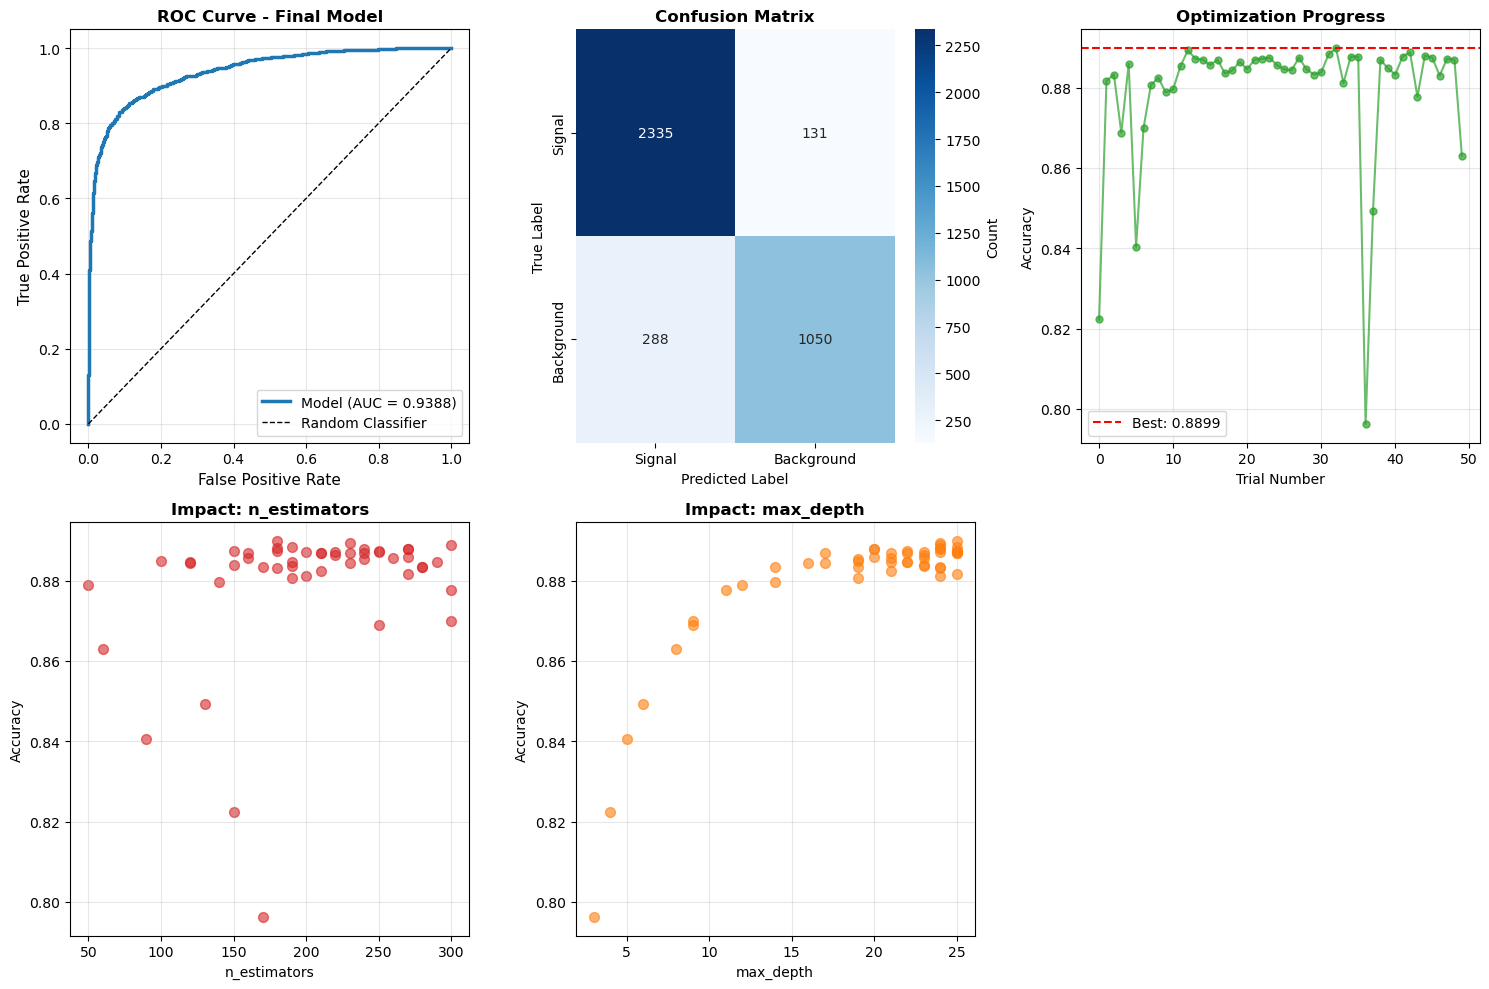

Visualization saved as 'gpu_optimization_analysis.png'


In [10]:
fig = plt.figure(figsize=(15, 10))

# Plot 1: ROC Curve
ax1 = plt.subplot(2, 3, 1)
ax1.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Model (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve - Final Model', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

ax2 = plt.subplot(2, 3, 2)

if hasattr(cm, 'to_numpy'):
    cm_array = cm.to_numpy()
elif hasattr(cm, 'get'):
    cm_array = cm.get()
else:
    cm_array = cm

sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', ax=ax2, 
            xticklabels=['Signal', 'Background'], 
            yticklabels=['Signal', 'Background'],
            cbar_kws={'label': 'Count'})

ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')
ax2.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

ax3 = plt.subplot(2, 3, 3)
ax3.plot(trials_df['trial_id'], trials_df['accuracy'], marker='o', linestyle='-', 
         color='#2ca02c', alpha=0.7, markersize=5)
ax3.axhline(y=study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
ax3.set_xlabel('Trial Number')
ax3.set_ylabel('Accuracy')
ax3.set_title('Optimization Progress', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

ax4 = plt.subplot(2, 3, 4)
ax4.scatter(trials_df['n_estimators'], trials_df['accuracy'], alpha=0.6, s=50, color='#d62728')
ax4.set_xlabel('n_estimators')
ax4.set_ylabel('Accuracy')
ax4.set_title('Impact: n_estimators', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

ax5 = plt.subplot(2, 3, 5)
ax5.scatter(trials_df['max_depth'], trials_df['accuracy'], alpha=0.6, s=50, color='#ff7f0e')
ax5.set_xlabel('max_depth')
ax5.set_ylabel('Accuracy')
ax5.set_title('Impact: max_depth', fontsize=12, fontweight='bold')
ax5.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gpu_optimization_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved as 'gpu_optimization_analysis.png'")

In [11]:
print(f"\nFinal Model Performance:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  ROC AUC:  {roc_auc:.4f}")

print(f"\nBest Hyperparameters Found:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")


Final Model Performance:
  Accuracy: 0.8899
  ROC AUC:  0.9388

Best Hyperparameters Found:
  n_estimators: 180
  max_depth: 25
  min_samples_split: 13
  min_samples_leaf: 1
